<a href="https://colab.research.google.com/github/CaroVisentin/analisis-churn-telco/blob/main/Customer_Churn_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn

In [40]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
df

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Existen TotalCharges vacios

In [42]:
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

problemas = df[df["TotalCharges_num"].isna()]
print(len(problemas))
problemas[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Se debe a que tenure es 0, por lo que TotalCharges = tenure * MonthlyCharges. Son usuarios nuevos.

In [43]:
df["TotalCharges"] = df["TotalCharges_num"].fillna(0)
df = df.drop(columns="TotalCharges_num")


Complete con 0 en TotalCharges donde los usuarios son nuevos.

Transformo datos para analisis

In [44]:
# Churn como 1/0 para poder calcular tasas con un promedio
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)

# SeniorCitizen viene como 0/1 y el resto como Yes/No: lo unifico
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Agrupar la antigüedad (en meses) en rangos
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 meses", "13-24 meses", "25-48 meses", "49-72 meses"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   object  
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

Analisis con SQL

In [8]:
import duckdb

def sql(query):
    return duckdb.sql(query).df()

sql("SELECT COUNT(*) AS clientes, AVG(churn_flag) AS tasa_churn FROM df")

,clientes,tasa_churn
0,7043,0.26537


In [9]:
churn_contrato = sql("""
    SELECT
        Contract,
        COUNT(*) AS clientes,
        SUM(churn_flag) AS bajas,
        ROUND(AVG(churn_flag) * 100, 1) AS tasa_churn_pct
    FROM df
    GROUP BY Contract
    ORDER BY tasa_churn_pct DESC
""")
churn_contrato

,Contract,clientes,bajas,tasa_churn_pct
0,Month-to-month,3875,1655.0,42.7
1,One year,1473,166.0,11.3
2,Two year,1695,48.0,2.8


churn_antiguedad: churn por tenure_group. Ordená por el grupo, no por la tasa, para que se vea la evolución en el tiempo.
churn_pago: churn por PaymentMethod.
churn_precio: compará el MonthlyCharges promedio de los que se fueron contra el de los que se quedaron. Pista: agrupá por Churn.
Bonus: churn por Contract y tenure_group juntos. Esta es la que suele dar el hallazgo más interesante del proyecto.

In [10]:
churn_antiguedad = sql("""SELECT
                        tenure_group,
                        COUNT(*) AS Clientes,
                        SUM(churn_flag) AS bajas,
                        ROUND(AVG(churn_flag) * 100, 1) AS tasa_churn_pct
                       FROM df
                       Group BY tenure_group
                       ORDER BY tenure_group
                      """)
churn_antiguedad

,tenure_group,Clientes,bajas,tasa_churn_pct
0,0-12 meses,2186,1037.0,47.4
1,13-24 meses,1024,294.0,28.7
2,25-48 meses,1594,325.0,20.4
3,49-72 meses,2239,213.0,9.5


In [11]:
churn_pago = sql("""SELECT
                        PaymentMethod,
                        COUNT(*) AS Clientes,
                        SUM(churn_flag) AS bajas,
                        ROUND(AVG(churn_flag) * 100, 1) AS tasa_churn_pct
                       FROM df
                       Group BY PaymentMethod
                       ORDER BY tasa_churn_pct DESC
                      """)
churn_pago

,PaymentMethod,Clientes,bajas,tasa_churn_pct
0,Electronic check,2365,1071.0,45.3
1,Mailed check,1612,308.0,19.1
2,Bank transfer (automatic),1544,258.0,16.7
3,Credit card (automatic),1522,232.0,15.2


In [12]:
churn_precio = sql("""SELECT
                        AVG(MonthlyCharges),
                        COUNT(*) AS Clientes,
                        churn_flag,
                        ROUND(AVG(churn_flag) * 100, 1) AS tasa_churn_pct
                       FROM df
                       Group BY churn_flag
                       ORDER BY tasa_churn_pct DESC
                      """)
churn_precio

,avg(MonthlyCharges),Clientes,churn_flag,tasa_churn_pct
0,74.441332,1869,1,100.0
1,61.265124,5174,0,0.0


In [13]:
churn_contract_tenuregorup = sql("""SELECT
                                tenure_group,
                                Contract,
                                COUNT(*) AS Clientes,
                                churn_flag
                              FROM df
                              Group BY Contract, tenure_group, churn_flag
                              ORDER BY Clientes DESC
                              """)
churn_contract_tenuregorup

,tenure_group,Contract,Clientes,churn_flag
0,49-72 meses,Two year,1221,0
1,0-12 meses,Month-to-month,1024,1
2,0-12 meses,Month-to-month,970,0
3,49-72 meses,One year,552,0
4,25-48 meses,Month-to-month,538,0
5,25-48 meses,One year,463,0
6,13-24 meses,Month-to-month,459,0
7,13-24 meses,Month-to-month,278,1
8,25-48 meses,Two year,268,0
9,25-48 meses,Month-to-month,264,1


In [18]:
churn_paymentmethod_contract = sql("""SELECT
                                tenure_group,
                                Contract,
                                 PaymentMethod,
                                COUNT(*) AS Clientes,
                                churn_flag
                              FROM df
                              WHERE churn_flag = 1
                              Group BY Contract, tenure_group, churn_flag, PaymentMethod
                              ORDER BY Clientes DESC
                              """)
churn_paymentmethod_contract

,tenure_group,Contract,PaymentMethod,Clientes,churn_flag
0,0-12 meses,Month-to-month,Electronic check,602,1
1,0-12 meses,Month-to-month,Mailed check,242,1
2,13-24 meses,Month-to-month,Electronic check,182,1
3,25-48 meses,Month-to-month,Electronic check,154,1
4,0-12 meses,Month-to-month,Bank transfer (automatic),101,1
5,0-12 meses,Month-to-month,Credit card (automatic),79,1
6,49-72 meses,Month-to-month,Electronic check,56,1
7,25-48 meses,Month-to-month,Bank transfer (automatic),52,1
8,25-48 meses,Month-to-month,Credit card (automatic),44,1
9,49-72 meses,One year,Electronic check,38,1


In [17]:
churn_contrato_antiguedad = sql("""
    SELECT
        Contract,
        tenure_group,
        COUNT(*) AS clientes,
        SUM(churn_flag) AS bajas,
        ROUND(AVG(churn_flag) * 100, 1) AS tasa_churn_pct
    FROM df
    GROUP BY Contract, tenure_group
    HAVING COUNT(*) >= 50
    ORDER BY Contract, tenure_group
""")
churn_contrato_antiguedad

,Contract,tenure_group,clientes,bajas,tasa_churn_pct
0,Month-to-month,0-12 meses,1994,1024.0,51.4
1,Month-to-month,13-24 meses,737,278.0,37.7
2,Month-to-month,25-48 meses,802,264.0,32.9
3,Month-to-month,49-72 meses,342,89.0,26.0
4,One year,0-12 meses,124,13.0,10.5
5,One year,13-24 meses,197,16.0,8.1
6,One year,25-48 meses,518,55.0,10.6
7,One year,49-72 meses,634,82.0,12.9
8,Two year,0-12 meses,68,0.0,0.0
9,Two year,13-24 meses,90,0.0,0.0


In [20]:
churn_contrato_metododepago = sql("""
    SELECT
        Contract,
        PaymentMethod,
        COUNT(*) AS clientes,
        SUM(churn_flag) AS bajas,
        ROUND(AVG(churn_flag) * 100, 1) AS tasa_churn_pct
    FROM df
    GROUP BY Contract, PaymentMethod
    HAVING COUNT(*) >= 50
    ORDER BY Contract, PaymentMethod
""")
churn_contrato_metododepago

,Contract,PaymentMethod,clientes,bajas,tasa_churn_pct
0,Month-to-month,Bank transfer (automatic),589,201.0,34.1
1,Month-to-month,Credit card (automatic),543,178.0,32.8
2,Month-to-month,Electronic check,1850,994.0,53.7
3,Month-to-month,Mailed check,893,282.0,31.6
4,One year,Bank transfer (automatic),391,38.0,9.7
5,One year,Credit card (automatic),398,41.0,10.3
6,One year,Electronic check,347,64.0,18.4
7,One year,Mailed check,337,23.0,6.8
8,Two year,Bank transfer (automatic),564,19.0,3.4
9,Two year,Credit card (automatic),581,13.0,2.2


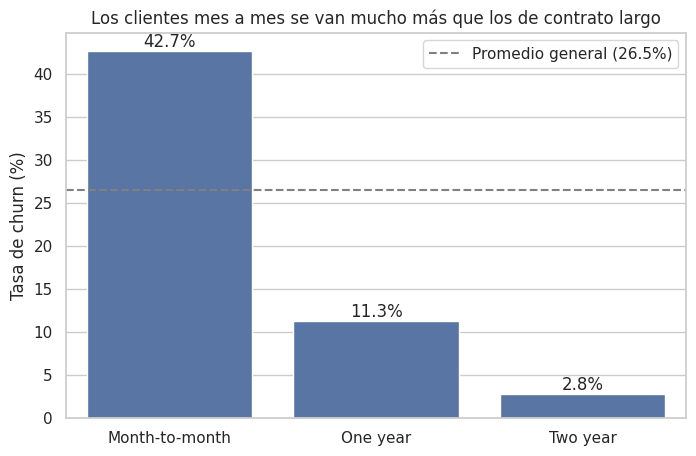

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
tasa_general = df["churn_flag"].mean() * 100

def grafico_barras(datos, columna, titulo, archivo, rotacion=0):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=datos, x=columna, y="tasa_churn_pct", color="#4C72B0", ax=ax)
    ax.axhline(tasa_general, ls="--", color="gray",
               label=f"Promedio general ({tasa_general:.1f}%)")
    ax.bar_label(ax.containers[0], fmt="%.1f%%")
    ax.set(title=titulo, xlabel="", ylabel="Tasa de churn (%)")
    ax.tick_params(axis="x", rotation=rotacion)
    ax.legend()
    plt.savefig(archivo, dpi=150, bbox_inches="tight")
    plt.show()

grafico_barras(churn_contrato, "Contract",
               "Los clientes mes a mes se van mucho más que los de contrato largo",
               "churn_contrato.png")

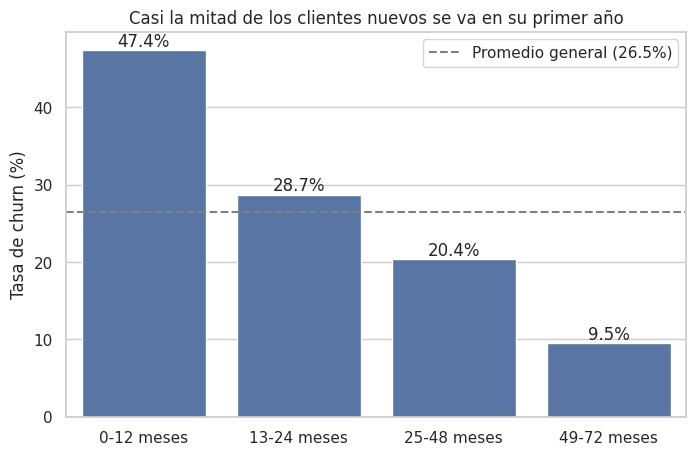

In [36]:
grafico_barras(churn_antiguedad, "tenure_group",
               "Casi la mitad de los clientes nuevos se va en su primer año",
               "churn_antiguedad.png")

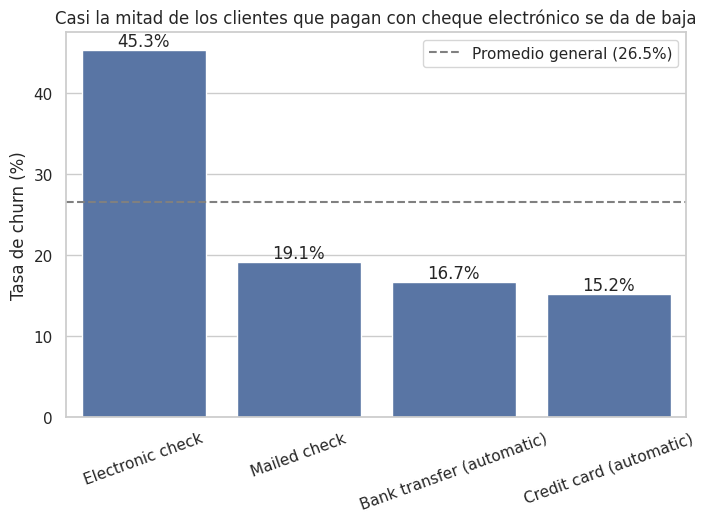

In [35]:
grafico_barras(churn_pago, "PaymentMethod",
               "Casi la mitad de los clientes que pagan con cheque electrónico se da de baja",
               "churn_pago.png"
               ,20)

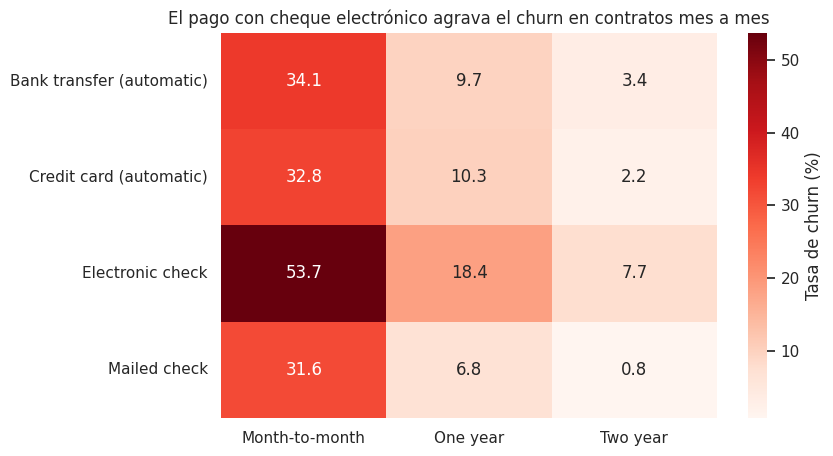

In [34]:
tabla = churn_contrato_metododepago.pivot(
    index="PaymentMethod", columns="Contract", values="tasa_churn_pct"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(tabla, annot=True, fmt=".1f", cmap="Reds", ax=ax,
            cbar_kws={"label": "Tasa de churn (%)"})
ax.set(title="El pago con cheque electrónico agrava el churn en contratos mes a mes",
       xlabel="", ylabel="")
plt.savefig("churn_contrato_pago.png", dpi=150, bbox_inches="tight")
plt.show()

## Hallazgos principales
- La tasa de churn general es del **26,5%**.
- **El tipo de contrato es el factor más fuerte:** los clientes mes a mes
  se van en un 42,7%, contra el 2,8% de los contratos a dos años.
- **El primer año es crítico:** el 47,4% de los clientes con hasta 12 meses
  de antigüedad se da de baja, y la tasa baja a 9,5% después de los 4 años.
- **El pago con cheque electrónico se asocia con más bajas** (45,3%, contra
  15-19% en los demás métodos), y el patrón se repite en los tres tipos
  de contrato. El peor caso: mes a mes + cheque electrónico, con 53,7%.

## Recomendaciones
1. Incentivar el pase a contratos anuales durante los primeros meses.
2. Reforzar la experiencia del primer año (onboarding, seguimiento).
3. Promover el débito automático con un beneficio, sobre todo en
   clientes mes a mes que pagan con cheque electrónico.

## Limitaciones
- Los resultados muestran asociaciones, no relaciones causales.
- Las variables se analizaron de a una o de a dos; otros factores
  podrían explicar parte de los efectos.
- Se trata de un dataset de ejemplo, no de datos reales de una empresa.